In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

import matplotlib.pyplot as plt

## 資料集準備

In [3]:
# Google股價資料可以從美國Yahoo金融網站下載：https://finance.yahoo.com/quote/GOOG/
# 訓練資料集2012/01/01-2016/12/31
# 測試資料集2017/01/01-2017/4/30

# 載入Google股價的訓練資料集
df_train = pd.read_csv("TSLA_Stock_Price_Train.csv",index_col="Date",parse_dates=True)
df_train.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-12-30,461.09,463.12,453.83,454.43,454.43,59238500
2025-12-29,469.00,469.40,459.00,459.64,459.64,66263000
2025-12-26,485.23,489.09,473.82,475.19,475.19,58780700
2025-12-24,488.48,490.90,476.80,485.40,485.40,41285400
2025-12-23,489.40,491.97,482.84,485.56,485.56,58223600


In [4]:
X_train_set = df_train.iloc[:,4:5].values  # Adj Close欄位
X_train_len = len(X_train_set)
print("筆數: ", X_train_len)

筆數:  1253


In [5]:
# 產生特徵資料和標籤資料
def create_dataset(ds, look_back=1):
  X_data, Y_data = [],[]
  for i in range(len(ds)-look_back):
    X_data.append(ds[i:(i+look_back), 0])
    Y_data.append(ds[i+look_back, 0])

  return np.array(X_data), np.array(Y_data)

In [6]:
# 設定回看天數
look_back = 60 # 請注意作業要求是回看60天。你可以試著測試其他天數的設定，但是作業繳交的模型檔，這個變數需要是60，若是其他數值的話，會導致老師無法讀取你的結果。

X_train, Y_train = create_dataset(X_train_set, look_back)
print("回看天數:", look_back)
print("X_train.shape: ", X_train.shape)
print("Y_train.shape: ", Y_train.shape)
print(X_train[0])
print(X_train[1])
print(Y_train[0])

回看天數: 60
X_train.shape:  (1193, 60)
Y_train.shape:  (1193,)
[454.43 459.64 475.19 485.4  485.56 488.73 481.2  483.37 467.26 489.88
 475.31 458.96 446.89 451.45 445.17 439.58 455.   454.53 446.74 429.24
 430.14 430.17 426.58 419.4  417.78 391.09 395.23 403.99 401.25 408.92
 404.35 401.99 430.6  439.62 445.23 429.52 445.91 462.07 444.26 468.37
 456.56 440.1  461.51 460.55 452.42 433.72 448.98 438.97 442.6  447.43
 439.31 428.75 435.15 429.24 435.9  413.49 435.54 438.69 433.09 453.25]
[459.64 475.19 485.4  485.56 488.73 481.2  483.37 467.26 489.88 475.31
 458.96 446.89 451.45 445.17 439.58 455.   454.53 446.74 429.24 430.14
 430.17 426.58 419.4  417.78 391.09 395.23 403.99 401.25 408.92 404.35
 401.99 430.6  439.62 445.23 429.52 445.91 462.07 444.26 468.37 456.56
 440.1  461.51 460.55 452.42 433.72 448.98 438.97 442.6  447.43 439.31
 428.75 435.15 429.24 435.9  413.49 435.54 438.69 433.09 453.25 429.83]
429.83


In [7]:
np.random.seed(20)  # 指定亂數種子 可嘗試輸入其他整數值 以獲得更理想的訓練結果

In [8]:
# 特徵標準化 - 正規化
sc = MinMaxScaler()
X_train_set2 = sc.fit_transform(X_train_set)

In [9]:
# 分割成特徵資料和標籤資料
X_train, Y_train = create_dataset(X_train_set2, look_back)
# 轉換成(樣本數, 時步, 特徵)張量
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print("X_train.shape: ", X_train.shape)
print("Y_train.shape: ", Y_train.shape)

X_train.shape:  (1193, 60, 1)
Y_train.shape:  (1193,)


## 打造LSTM模型預測google股價

In [10]:
# 定義模型
model = Sequential()
model.add(LSTM(50, return_sequences=True,input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.summary()   # 顯示模型摘要資訊

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 編譯模型
model.compile(loss="mse", optimizer="adam")
# 訓練模型
model.fit(X_train, Y_train, epochs=100, batch_size=32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0247
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0073
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0064
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0059
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0055
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0047
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0047
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0045
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0043
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0036
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

In [12]:
# 使用模型預測股價 - 2017年1~3月預測 4月份股價
df_test = pd.read_csv("TSLA_Stock_Price_Test.csv")
X_test_set = df_test.iloc[:,4:5].values
X_test_set2 = sc.transform(X_test_set) # 特徵標準化
# 產生特徵資料和標籤資料
X_test, Y_test = create_dataset(X_test_set2, look_back)
# 轉換成(樣本數, 時步, 特徵)張量
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [13]:
X_test_pred = model.predict(X_test)
# 將（被標準化過的）預測值與實際值轉換回真實股價數值
X_test_pred_price = sc.inverse_transform(X_test_pred)
Y_test_price = sc.inverse_transform(Y_test.reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


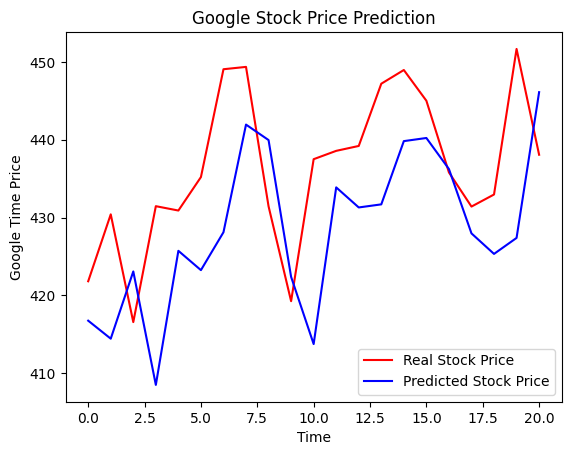

In [14]:
# 繪出股價圖表
plt.plot(Y_test_price, color="red", label="Real Stock Price")
plt.plot(X_test_pred_price, color="blue", label="Predicted Stock Price")
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Google Time Price")
plt.legend()
plt.show()

In [15]:
# 儲存Keras模型
model.save("413570012_TSLA_RNN.keras")



---



## 作業：實作案例 特斯拉公司美股股價預測 (美股代號: TSLA)
#### 蒐集過去五年的股價資料建立並訓練模型
#### 以今年初到四月底的股價為預測資料
#### 回看60筆數據（一季1~3月)，來預測後續(4月份)價格走勢
##### 訓練資料2020/01/01-2024/12/31
##### 測試資料2025/01/01-2025/4/30
######  (與教學影片裡的範例程式碼內所使用的日期不同，請以TronClass上作業要求說明的時間為準，測試資料應為現下今年的資料)
######  (請留意你的回看天數是否是60天。亂數種子可以任意更改成其他整數，可能會得到更佳的結果)

In [16]:
from sklearn.metrics import mean_squared_error

In [17]:
# 計算MSE
mse = mean_squared_error(Y_test, X_test_pred)
# 計算RMSE
rmse = np.sqrt(mse)

In [18]:
rmse # 此評估指標越低越好，最低為0

np.float64(0.03292361683994919)

In [19]:
# 作業計算公式
def rmse_to_score(rmse, rmse_max):
    """
    將 RMSE 值轉換為 60 到 100 分的分數。

    參數:
    rmse: float - 學生模型的 RMSE 值。
    rmse_max: float - 設定的 RMSE 最大值，當 RMSE 為此值時對應分數為 60 分。

    返回:
    score: float - 計算出的分數，範圍在 60 到 100 分之間。
    """
    if rmse < 0:
        raise ValueError("RMSE 不能為負數。")
    if rmse > rmse_max:
        return 60  # 如果 RMSE 超過最大值，分數為最低分 60 分
    score = 100 - (rmse / rmse_max) * 60
    return score

# RMSE 最大值
rmse_max_value = 0.08  # 這個值老師會根據全班同學的具體情況調整

In [20]:
score = rmse_to_score(rmse, rmse_max_value)
print(f"你的RMSE 為 {rmse} 。其轉換成作業的分數是：{score:.2f}")

你的RMSE 為 0.03292361683994919 。其轉換成作業的分數是：75.31
